In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/Cleaned_Dataset_IntermodalRail.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 257
Columns: 19


In [3]:
df.head()


,shipment_id,transport_mode,recorded_date,recorded_time,recorded_datetime,origin_location,destination_location,cargo_type,temperature_celsius,humidity_percentage,vibration_level,pressure_kpa,exposure_duration_hours,door_open_count,salinity_ppt,thermal_leakage_score,spoilage_risk_percent,remaining_shelf_life_days,spoilage_status
0,RAIL1001,Intermodal Rail,2025-07-18,10:00,2025-07-18 10:00:00,Mumbai,Kochi,Flowers,3.8,62.4,1.8,0.0,159.2,0,0.0,4.5,20.3,4.0,Fresh
1,RAIL0681,Intermodal Rail,2025-03-01,10:45,2025-03-01 10:45:00,Kolkata,Kochi,Flowers,4.5,47.4,4.3,0.0,143.1,0,0.0,4.3,13.5,4.7,Fresh
2,RAIL0086,Intermodal Rail,2024-11-09,01:05,2024-11-09 01:05:00,Kolkata,Bengaluru,Meat,3.1,35.8,0.4,0.0,141.9,0,0.0,3.2,18.7,5.2,Fresh
3,RAIL0432,Intermodal Rail,2024-11-30,04:35,2024-11-30 04:35:00,Kolkata,Jammu,Pharmaceuticals,7.2,50.7,2.6,0.0,153.1,0,0.0,1.4,8.3,28.2,Fresh
4,RAIL0624,Intermodal Rail,2025-06-25,08:15,2025-06-25 08:15:00,Mumbai,Nagpur,Fruits,11.5,34.1,3.0,0.0,140.2,0,0.0,3.4,8.8,11.0,Fresh


In [4]:
print("Column names:")
print(df.columns.tolist())


Column names:
['shipment_id', 'transport_mode', 'recorded_date', 'recorded_time', 'recorded_datetime', 'origin_location', 'destination_location', 'cargo_type', 'temperature_celsius', 'humidity_percentage', 'vibration_level', 'pressure_kpa', 'exposure_duration_hours', 'door_open_count', 'salinity_ppt', 'thermal_leakage_score', 'spoilage_risk_percent', 'remaining_shelf_life_days', 'spoilage_status']


In [5]:
df["temperature_celsius"].describe()

count    257.000000
mean       4.904280
std        3.980021
min       -5.000000
25%        2.300000
50%        3.900000
75%        7.500000
max       23.000000
Name: temperature_celsius, dtype: float64

In [6]:
temperature_by_spoilage = df.groupby(
    "spoilage_status"
)["temperature_celsius"].mean()

print(temperature_by_spoilage)

spoilage_status
At Risk    5.007143
Fresh      4.895798
Spoiled    5.020000
Name: temperature_celsius, dtype: float64


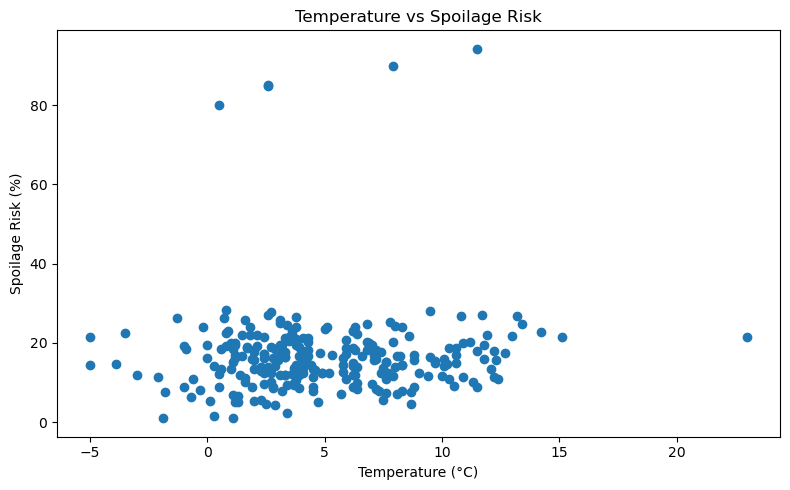

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["temperature_celsius"],
    df["spoilage_risk_percent"]
)

plt.title("Temperature vs Spoilage Risk")
plt.xlabel("Temperature (°C)")
plt.ylabel("Spoilage Risk (%)")

plt.tight_layout()
plt.show()

In [8]:
correlation = df[
    ["temperature_celsius", "spoilage_risk_percent"]
].corr()

print("Correlation between Temperature and Spoilage Risk:")
print(correlation)

Correlation between Temperature and Spoilage Risk:
                       temperature_celsius  spoilage_risk_percent
temperature_celsius                  1.000                  0.067
spoilage_risk_percent                0.067                  1.000


In [9]:
temperature_risk_correlation = df[
    "temperature_celsius"
].corr(
    df["spoilage_risk_percent"]
)

print(
    "Temperature vs Spoilage Risk Correlation:",
    temperature_risk_correlation
)

Temperature vs Spoilage Risk Correlation: 0.06700007389964456


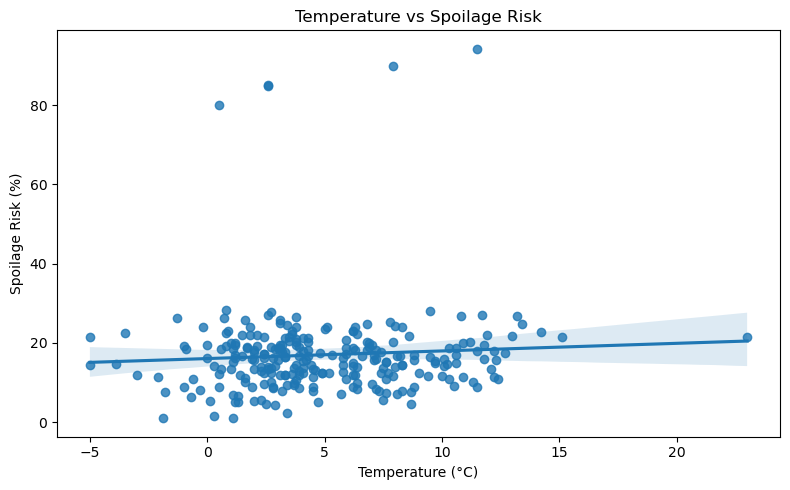

In [10]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="temperature_celsius",
    y="spoilage_risk_percent"
)

plt.title("Temperature vs Spoilage Risk")
plt.xlabel("Temperature (°C)")
plt.ylabel("Spoilage Risk (%)")

plt.tight_layout()
plt.show()
